## Loading Packages

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import folium

## Loading the Data

In [2]:
weather_daily = pd.read_csv('../data/citibike/JC/jersey_weather_2025.csv')
citibike_df = pd.read_csv('../data/citibike/JC/JC2025_Enriched.csv')

In [3]:
# Converting into dates

weather_daily['date'] = pd.to_datetime(weather_daily['date'], errors="coerce")
citibike_df['date'] = pd.to_datetime(citibike_df['date'], errors="coerce")

In [4]:
citibike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999225 entries, 0 to 999224
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ride_id                999225 non-null  str           
 1   rideable_type          999225 non-null  str           
 2   started_at             999225 non-null  str           
 3   ended_at               999225 non-null  str           
 4   start_station_name     999224 non-null  str           
 5   start_station_id       999224 non-null  str           
 6   end_station_name       998439 non-null  str           
 7   end_station_id         998282 non-null  str           
 8   start_lat              999225 non-null  float64       
 9   start_lng              999225 non-null  float64       
 10  end_lat                999225 non-null  float64       
 11  end_lng                999225 non-null  float64       
 12  member_casual          999225 non-null  str           


In [5]:
weather_daily.info

<bound method DataFrame.info of           date  temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
0   2025-01-01                10.9                 3.9                  7.4   
1   2025-01-02                 5.4                 0.3                  2.6   
2   2025-01-03                 3.2                -1.9                  0.4   
3   2025-01-04                -0.1                -2.7                 -1.4   
4   2025-01-05                 0.3                -3.6                 -2.2   
..         ...                 ...                 ...                  ...   
360 2025-12-27                -1.0                -7.3                 -3.6   
361 2025-12-28                 1.0               -11.6                 -5.8   
362 2025-12-29                 7.3                -1.4                  3.5   
363 2025-12-30                -0.2                -3.0                 -1.3   
364 2025-12-31                -0.2                -3.7                 -2.2   

     precipitation_

## Data Preperation

### Daily Data

In [6]:
daily_rides = (
    citibike_df
    .groupby("date", as_index=False)
    .agg(
        number_of_rides=("ride_id", "count")
    )
)
daily_rides["date"] = pd.to_datetime(daily_rides["date"])
daily_rides


,date,number_of_rides
0,2024-12-31,2
1,2025-01-01,1179
2,2025-01-02,1710
3,2025-01-03,1770
4,2025-01-04,1337
...,...,...
361,2025-12-27,287
362,2025-12-28,488
363,2025-12-29,952
364,2025-12-30,1142


### Monthly Data

In [7]:
monthly_rides = (
    citibike_df
    .groupby("month", as_index=False)
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

monthly_rides

,month,number_of_rides
0,2024-12,2
1,2025-01,50589
2,2025-02,45250
3,2025-03,73277
4,2025-04,81533
5,2025-05,93202
6,2025-06,96736
7,2025-07,107374
8,2025-08,108001
9,2025-09,115580


### Merging

In [8]:
bike_weather_daily = daily_rides.merge(
    weather_daily,
    on="date",
    how="left"
)
bike_weather_daily.head()

,date,number_of_rides,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2024-12-31,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,1179,10.9,3.9,7.4,4.5,4.5,0.0,23.2
2,2025-01-02,1710,5.4,0.3,2.6,0.0,0.0,0.0,25.1
3,2025-01-03,1770,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
4,2025-01-04,1337,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1


## Visualization

In [9]:
fig = px.line(
    weather_daily,
    x="date",
    y="temperature_2m_mean",
    title="Daily Average Temperature Over Time",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average Temperature",
    hovermode="x unified"
)

fig.show()

In [10]:
import plotly.express as px
fig = px.line(
    weather_daily,
    x="date",
    y="wind_speed_10m_max",
    title="Daily Maximum Wind Spead Over Time",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Wind Speed km/h",
    hovermode="x unified"
)

fig.show()

In [11]:
temperature_long = weather_daily.melt(
    id_vars= 'date',
    value_vars =  [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean"
    ],
    var_name =  "temperature_type",
    value_name = "temperature"
)

temperature_long

,date,temperature_type,temperature
0,2025-01-01,temperature_2m_max,10.9
1,2025-01-02,temperature_2m_max,5.4
2,2025-01-03,temperature_2m_max,3.2
3,2025-01-04,temperature_2m_max,-0.1
4,2025-01-05,temperature_2m_max,0.3
...,...,...,...
1090,2025-12-27,temperature_2m_mean,-3.6
1091,2025-12-28,temperature_2m_mean,-5.8
1092,2025-12-29,temperature_2m_mean,3.5
1093,2025-12-30,temperature_2m_mean,-1.3


In [12]:
fig = px.line(
    temperature_long,
    x="date",
    y="temperature",
    color="temperature_type",
    title="Daily Temperature: Maximum, Minimum, and Average",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Temperature",
    # hovermode="x unified"
)

fig.show()

In [13]:
season_rides = (
    citibike_df
    .groupby("season", as_index=False)
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]

season_rides["season"] = pd.Categorical(
    season_rides["season"],
    categories=season_order,
    ordered=True
)

season_rides = season_rides.sort_values("season")

season_rides

,season,number_of_rides
3,Winter,143703
1,Spring,248012
2,Summer,312111
0,Autumn,295399


In [14]:
fig = px.bar(
    season_rides,
    x="season",
    y="number_of_rides",
    title="Number of Citi Bike Rides per Season",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Season",
    yaxis_title="Number of Rides"
)

fig.show()

In [15]:
top_start_stations = (
    citibike_df
    .dropna(subset=["start_station_name"])
    .groupby("start_station_name", as_index=False)
    .agg(
        number_of_departures=("ride_id", "count")
    )
    .sort_values("number_of_departures", ascending=False)
    .head(10)
)

top_start_stations

,start_station_name,number_of_departures
52,Grove St PATH,45004
58,Hoboken Terminal - Hudson St & Hudson Pl,25889
53,Hamilton Park,22259
95,River St & Newark St,21383
86,Newport PATH,20663
18,Bergen Ave & Sip Ave,20398
44,Exchange Pl,20008
0,11 St & Washington St,19481
94,River St & 1 St,19143
87,Newport Pkwy,18720


In [16]:
top_end_stations = (
    citibike_df
    .dropna(subset=["end_station_name"])
    .groupby("end_station_name", as_index=False)
    .agg(
        number_of_arrivals=("ride_id", "count")
    )
    .sort_values("number_of_arrivals", ascending=False)
    .head(10)
)

top_end_stations

,end_station_name,number_of_arrivals
232,Grove St PATH,47758
241,Hoboken Terminal - Hudson St & Hudson Pl,26639
233,Hamilton Park,22353
347,River St & Newark St,22113
317,Newport PATH,20701
73,Bergen Ave & Sip Ave,20368
207,Exchange Pl,20160
7,11 St & Washington St,19505
318,Newport Pkwy,18707
346,River St & 1 St,18515


In [17]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20,Autumn


In [18]:
top_end_stations = (
    citibike_df
    # .dropna(subset=["end_station_name"])
    .groupby(["start_station_name","end_station_name"], as_index=False)
    .agg(
        number_of_arrivals=("ride_id", "count")
    )
    .sort_values("number_of_arrivals", ascending=False)
    .head(10)
)

top_end_stations

,start_station_name,end_station_name,number_of_arrivals
5218,Hoboken Terminal - Hudson St & Hudson Pl,Hoboken Ave at Monmouth St,4559
6944,McGinley Square,Bergen Ave & Sip Ave,4310
4544,Grove St PATH,Marin Light Rail,4131
6750,Marin Light Rail,Grove St PATH,3832
4537,Grove St PATH,Liberty Light Rail,3750
1823,Bergen Ave & Sip Ave,McGinley Square,3609
6132,Liberty Light Rail,Grove St PATH,3605
5125,Hoboken Ave at Monmouth St,Hoboken Terminal - Hudson St & Hudson Pl,3257
2186,Brunswick St,Grove St PATH,3178
4636,Hamilton Park,Grove St PATH,3000


In [19]:
fig = px.bar(
    top_start_stations.sort_values("number_of_departures"),
    x="number_of_departures",
    y="start_station_name",
    orientation="h",
    title="Top 10 Start Stations by Number of Departures",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Number of Departures",
    yaxis_title="Start Station"
)

fig.show()

In [20]:
fig = px.bar(
    top_end_stations.sort_values("number_of_arrivals"),
    x="number_of_arrivals",
    y="end_station_name",
    orientation="h",
    title="Top 10 End Stations by Number of Arrivals",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Number of Arrivals",
    yaxis_title="End Station"
)

fig.show()


In [21]:
fig = px.scatter(
    bike_weather_daily,
    x="temperature_2m_mean",
    y="number_of_rides",
    trendline="ols",
    title="Daily Rides vs Average Temperature"
)

fig.update_layout(
    xaxis_title="Average Daily Temperature",
    yaxis_title="Number of Rides"
)

fig.show()

In [22]:
fig = px.scatter(
    bike_weather_daily,
    x="wind_speed_10m_max",
    y="number_of_rides",
    trendline="ols",
    title="Daily Rides vs Maximum Wind Speed"
)

fig.update_layout(
    xaxis_title="Maximum Wind Speed",
    yaxis_title="Number of Rides"
)

fig.show()

In [23]:
fig = px.scatter(
    bike_weather_daily,
    x="precipitation_sum",
    y="number_of_rides",
    trendline="ols", # ordinary least squered
    title="Daily Rides vs Precipitation"
)

fig.update_layout(
    xaxis_title="Daily Precipitation",
    yaxis_title="Number of Rides"
)

fig.show()

In [24]:

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=bike_weather_daily["date"],
        y=bike_weather_daily["number_of_rides"],
        mode="lines",
        name="Daily Rides",
        yaxis="y1"
    )
)

fig.add_trace(
    go.Scatter(
        x=bike_weather_daily["date"],
        y=bike_weather_daily["temperature_2m_mean"],
        mode="lines",
        name="Daily Average Temperature",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Daily Rides and Daily Average Temperature",
    xaxis=dict(
        title="Day"
    ),
    yaxis=dict(
        title="Daily Rides",
        side="left"
    ),
    yaxis2=dict(
        title="Daily Average Temperature",
        overlaying="y",
        side="right"
    ),
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()

## Geopandas


In [25]:
import geopandas as gpd
from urllib.parse import urlencode
from pathlib import Path


url = '../data/citibike/JC/jersey-city-neighborhoods.geojson' # .shp shape file

jersey_city = gpd.read_file(url)

jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


In [26]:
jersey_city.to_file('dataframe.geojson', driver='GeoJSON')

In [27]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

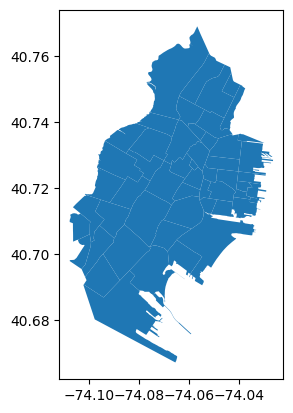

In [28]:
jersey_city.plot()

### Start Station

```sql
SELECT start_station_id as station_id FROM DEPARTURE 
UNION ALL
SELECT end_station_id as station_id FROM ARRIVALS 
```

In [29]:
start_stations = citibike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()

start_stations = start_stations.rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng"
    }
)

start_stations["activity_type"] = "departure"

start_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC094,Glenwood Ave,40.727551,-74.071061,departure
1,B6C773B13AC0E465,JC094,Glenwood Ave,40.727551,-74.071061,departure
2,C300465AA158280F,HB203,Bloomfield St & 15 St,40.754530,-74.026580,departure
3,31A424FC97C8AAFB,HB303,Clinton St & 7 St,40.745420,-74.033320,departure
4,08C5EA04CB1FDC57,HB303,Clinton St & 7 St,40.745420,-74.033320,departure


In [30]:

end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()

end_stations = end_stations.rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng"
    }
)

end_stations["activity_type"] = "arrival"

end_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC131,West Side Ave & Stegman Pkwy,40.710870,-74.093680,arrival
1,B6C773B13AC0E465,JC131,West Side Ave & Stegman Pkwy,40.710870,-74.093680,arrival
2,C300465AA158280F,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival
3,31A424FC97C8AAFB,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival
4,08C5EA04CB1FDC57,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival


In [31]:
station_arrivals = (
    citibike_df

    .groupby(
        [
            "end_station_id",
            "end_station_name",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        total_arrivals=("ride_id", "count")
    )
    .sort_values("total_arrivals", ascending=False)
)

station_arrivals.head()

,end_station_id,end_station_name,end_lat,end_lng,total_arrivals
461,JC115,Grove St PATH,40.719410,-74.043090,47744
376,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638
413,JC009,Hamilton Park,40.727596,-74.044247,22347
380,HB106,River St & Newark St,40.736722,-74.029007,22113
435,JC066,Newport PATH,40.727224,-74.033759,20698


In [32]:
station_activity_long = pd.concat(
    [
        start_stations,
        end_stations
    ],
    ignore_index=True
)

station_activity_long = station_activity_long.dropna(
    subset=[
        "station_id",
        "station_name",
        "lat",
        "lng"
    ]
)

station_activity_long.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC094,Glenwood Ave,40.727551,-74.071061,departure
1,B6C773B13AC0E465,JC094,Glenwood Ave,40.727551,-74.071061,departure
2,C300465AA158280F,HB203,Bloomfield St & 15 St,40.754530,-74.026580,departure
3,31A424FC97C8AAFB,HB303,Clinton St & 7 St,40.745420,-74.033320,departure
4,08C5EA04CB1FDC57,HB303,Clinton St & 7 St,40.745420,-74.033320,departure


In [33]:
station_activity_agg = (
    station_activity_long
    .groupby(
        [
            "station_id",
            "station_name",
            "lat",
            "lng",
            "activity_type"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values('station_name')
)

station_activity_agg.tail()

,station_id,station_name,lat,lng,activity_type,number_of_rides
572,JC130,Woodlawn Ave & Sterling Ave,40.707300,-74.092430,arrival,7
573,JC130,Woodlawn Ave & Sterling Ave,40.707300,-74.092430,departure,7
140,5558.04,Wythe Ave & N 13 St,40.722767,-73.957021,arrival,5
524,JC097,York St & Marin Blvd,40.716615,-74.042412,arrival,5651
525,JC097,York St & Marin Blvd,40.716615,-74.042412,departure,5573


In [34]:
station_summary = (
    station_activity_agg
    .pivot_table(
        index=[
            "station_id",
            "station_name",
            "lat",
            "lng"
        ],
        columns="activity_type",
        values="number_of_rides",
        fill_value=0
    )
    .reset_index()
)

station_summary.tail()

activity_type,station_id,station_name,lat,lng,arrival,departure
483,JC140,Caven Point Recreation Fields,40.69222,-74.08025,9.0,12.0
484,JC142,Culver Ave & JFK Blvd,40.71005,-74.08576,24.0,28.0
485,JC143,MLK Dr & Bayview Ave,40.70710,-74.08335,7.0,6.0
486,JC144,Danforth Ave & JFK Blvd,40.70056,-74.09474,7.0,6.0
487,JC145,Mallory Ave & Roosevelt Ave,40.72203,-74.08596,28.0,24.0


In [35]:

station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)


In [36]:

station_summary["total_activity"] = station_summary["total_departures"] + station_summary["total_arrivals"]

station_summary.head()



activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0,1.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,1.0,0.0,1.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,1.0,0.0,1.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,1.0,0.0,1.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,1.0,0.0,1.0


In [37]:
# arrival = ժամանում, end
# departure = մեկնում, start
station_summary["net_arrivals"] =  station_summary["total_arrivals"] - station_summary["total_departures"] 

station_summary.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_arrivals
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0,1.0,1.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,1.0,0.0,1.0,1.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,1.0,0.0,1.0,1.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,1.0,0.0,1.0,1.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,1.0,0.0,1.0,1.0


In [38]:

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_arrivals
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,45004.0,92748.0,2740.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25889.0,52527.0,749.0
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22259.0,44606.0,88.0
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,730.0
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20663.0,41361.0,35.0


In [39]:
station_summary.tail()



activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_arrivals
483,7052.01,W 63 St & Broadway,40.771639,-73.982614,1.0,0.0,1.0,1.0
484,7113.08,East End Ave & E 86 St,40.775186,-73.944461,1.0,0.0,1.0,1.0
485,7121.02,E 80 St & 2 Ave,40.773914,-73.954395,1.0,0.0,1.0,1.0
486,7123.04,W 64 St & Thelonious Monk Circle,40.775160,-73.989187,1.0,0.0,1.0,1.0
487,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0,1.0,1.0


In [40]:
# long, late

station_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 488 entries, 0 to 487
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   station_id        488 non-null    str    
 1   station_name      488 non-null    str    
 2   lat               488 non-null    float64
 3   lng               488 non-null    float64
 4   total_arrivals    488 non-null    float64
 5   total_departures  488 non-null    float64
 6   total_activity    488 non-null    float64
 7   net_arrivals      488 non-null    float64
dtypes: float64(6), str(2)
memory usage: 43.1 KB


In [41]:
# wkt
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry = gpd.points_from_xy(station_summary['lng'],
                                  station_summary['lat']                                     
                                  ),
    crs = "EPSG: 4326"
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_arrivals,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,45004.0,92748.0,2740.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25889.0,52527.0,749.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22259.0,44606.0,88.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,730.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20663.0,41361.0,35.0,POINT (-74.03376 40.72722)


In [42]:
station_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 488 entries, 0 to 487
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   station_id        488 non-null    str     
 1   station_name      488 non-null    str     
 2   lat               488 non-null    float64 
 3   lng               488 non-null    float64 
 4   total_arrivals    488 non-null    float64 
 5   total_departures  488 non-null    float64 
 6   total_activity    488 non-null    float64 
 7   net_arrivals      488 non-null    float64 
 8   geometry          488 non-null    geometry
dtypes: float64(6), geometry(1), str(2)
memory usage: 46.9 KB


<Axes: >

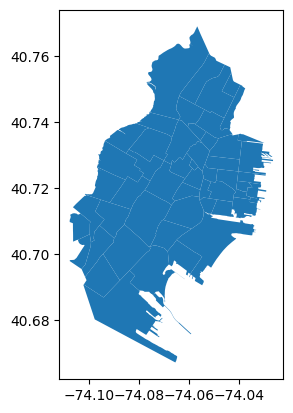

In [43]:
jersey_city.plot()

In [44]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20,Autumn


```sql
SELECT 
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng",
            COUNT(ride_id) AS number_of_rides
FROM citibike_df
GROUP BY  
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
ORDER BY COUNT(ride_id) DESC
```

In [45]:
route_summary = (citibike_df.groupby(
    [       
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
    ],
    as_index = False   
    )
.agg(
    number_of_rides = ('ride_id',"count")
)
.sort_values('number_of_rides', ascending = False)
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750


In [46]:
route_summary['route'] = route_summary['start_station_id'] + "->" + route_summary['end_station_id']
route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559,HB101->JC105
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306,JC055->JC109
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131,JC115->JC013
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831,JC013->JC115
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750,JC115->JC052


In [47]:
top_20_routes = route_summary.head(20)
top_20_routes[['route','number_of_rides', 'start_lat',	'start_lng',	'end_lat',	'end_lng']]

top_20_routes.to_csv('../data/citibike/JC/top20routes.csv', index=False)

start lat, long
end  lat, long

## Routes

In [48]:
center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

In [49]:
from IPython.display import display
line_map = folium.Map(
    location=[center_lat,center_lng],
    zoom_start = 10
)

from IPython.display import display

max_rides = top_20_routes['number_of_rides'].max()

In [50]:
top_20_routes.tail()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
6745,JC078,Lafayette Park,JC115,Grove St PATH,40.713464,-74.062859,40.719410,-74.043090,2531,JC078->JC115
6559,JC076,Dixon Mills,JC115,Grove St PATH,40.721630,-74.049968,40.719410,-74.043090,2515,JC076->JC115
8755,JC115,Grove St PATH,JC110,JC Medical Center,40.719410,-74.043090,40.715391,-74.049692,2498,JC115->JC110
8737,JC115,Grove St PATH,JC078,Lafayette Park,40.719410,-74.043090,40.713464,-74.062859,2444,JC115->JC078
8715,JC115,Grove St PATH,JC023,Brunswick St,40.719410,-74.043090,40.724176,-74.050656,2343,JC115->JC023


In [51]:
top_20_routes.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559,HB101->JC105
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306,JC055->JC109
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131,JC115->JC013
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831,JC013->JC115
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750,JC115->JC052


https://python-visualization.github.io/folium/latest/user_guide/vector_layers/polyline.html

In [ ]:
for _, row in top_20_routes.iterrows():

    start_point = [row['start_lat'],row['start_lng']]
    end_point = [row['end_lat'],row['end_lng']]
    
    line_weight = 1 + (row['number_of_rides']/max_rides)*5

    folium.PolyLine(
        locations = [start_point,end_point],
        weight = line_weight,
        opacity = 0.7,
        
        popup = f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """

    ).add_to(line_map)

line_map


In [56]:
jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


In [57]:
station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_arrivals,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,45004.0,92748.0,2740.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25889.0,52527.0,749.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22259.0,44606.0,88.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,730.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20663.0,41361.0,35.0,POINT (-74.03376 40.72722)


In [ ]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how = "inner",
    predicate = "within"
)


station_neighborhood.head

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_arrivals,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,45004.0,92748.0,2740.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22259.0,44606.0,88.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20663.0,41361.0,35.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,20357.0,20398.0,40755.0,-41.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,20142.0,20008.0,40150.0,134.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


In [60]:
station_neighborhood.shape

(79, 18)

In [61]:
neighborhood_activity = (
    station_neighborhood
    .groupby(
        'neighborhood',
        as_index= False
    )
    .agg(
        
        number_of_stations = ('station_id', 'nunique'),
        total_departures = ("total_departures",'sum'),
        total_arrivals =   ("total_arrivals",'sum'),
        total_activity = ("total_activity",'sum')
         

    )
)


neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity
0,Bayside,2,50.0,59.0,109.0
1,Bergen Hill,4,23808.0,22888.0,46696.0
2,Exchange Place,1,20008.0,20142.0,40150.0
3,Gregory Park,1,16221.0,16149.0,32370.0
4,Hamilton Park,2,31762.0,31922.0,63684.0


In [63]:
neighborhood_activity['avg_activity_per_station'] = neighborhood_activity['total_arrivals']/neighborhood_activity['number_of_stations']
neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Bayside,2,50.0,59.0,109.0,29.5
1,Bergen Hill,4,23808.0,22888.0,46696.0,5722.0
2,Exchange Place,1,20008.0,20142.0,40150.0,20142.0
3,Gregory Park,1,16221.0,16149.0,32370.0,16149.0
4,Hamilton Park,2,31762.0,31922.0,63684.0,15961.0


In [64]:
station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_arrivals,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,45004.0,92748.0,2740.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25889.0,52527.0,749.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22259.0,44606.0,88.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,730.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20663.0,41361.0,35.0,POINT (-74.03376 40.72722)


In [67]:
station_points_map = folium.Map(
    location=[center_lat,center_lng],
    zoom_start= 10
)

In [68]:
for _, row in station_gdf.iterrows():
    folium.CircleMarker(
        location = [
                    row['geometry'].y,
                    row['geometry'].x,
                    ],
        radius = 3,
        popup = f"""{row['station_id']}""",
        opacity = 0.5
        
    ).add_to(station_points_map)

In [70]:
station_points_map

In [71]:
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborhood',
    how="left"
)

neighborhood_choropleth_gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,12.0,9.0,21.0,9.000000
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",NaN,NaN,NaN,NaN,NaN
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,30896.0,30730.0,61626.0,5121.666667
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,6173.0,6045.0,12218.0,377.812500


In [72]:
def create_neighborhood_choropleth(
    gdf,
    metric,
    legend_name,
    neighborhood_col="neighborhood"
):
    choropleth_map = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=12
    )

    folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=[neighborhood_col, metric],
        key_on=f"feature.properties.{neighborhood_col}",
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name=legend_name,
        nan_fill_opacity=0.1
    ).add_to(choropleth_map)

    folium.GeoJson(
        gdf,
        name="Neighborhood Boundaries",
        tooltip=folium.GeoJsonTooltip(
            fields=[
                neighborhood_col,
                metric
            ],
            aliases=[
                "Neighborhood:",
                f"{legend_name}:"
            ],
            localize=True
        ),
        style_function=lambda feature: {
            "fillOpacity": 0,
            "color": "black",
            "weight": 1
        }
    ).add_to(choropleth_map)

    folium.LayerControl().add_to(choropleth_map)

    return choropleth_map

In [73]:
total_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_activity",
    legend_name="Total Citi Bike Activity",
    neighborhood_col="neighborhood"
)

total_activity_map